Libraries imported successfully!
TensorFlow version: 2.19.0

📥 Loading MNIST dataset...
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)
✅ Data preprocessing complete!

🔧 Building CNN model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


🏋️ Training model...
Epoch 1/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 36s 94ms/step - accuracy: 0.9224 - loss: 0.2611 - val_accuracy: 0.9776 - val_loss: 0.0732
Epoch 2/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 95ms/step - accuracy: 0.9765 - loss: 0.0746 - val_accuracy: 0.9780 - val_loss: 0.0665
Epoch 3/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 88ms/step - accuracy: 0.9839 - loss: 0.0518 - val_accuracy: 0.9862 - val_loss: 0.0448

✅ Test accuracy: 99.00%

🔍 Sample predictions from test set:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


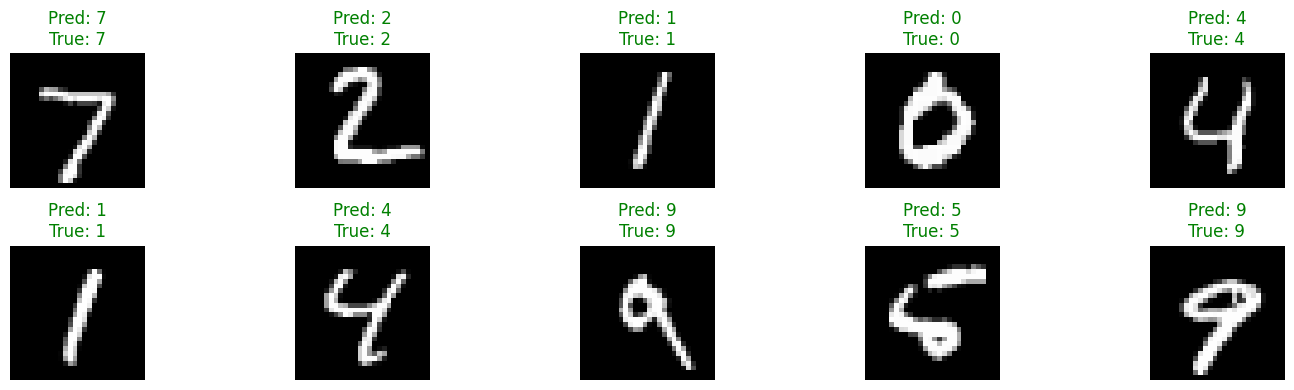


🎨 Draw a digit below and click 'Predict'



✅ Drawing interface ready! Draw a digit and click Predict.
💾 Model will be saved after testing...

✅ Model saved as 'mnist_digit_recognizer.keras'

📝 Let's also test with some digits from the test set:


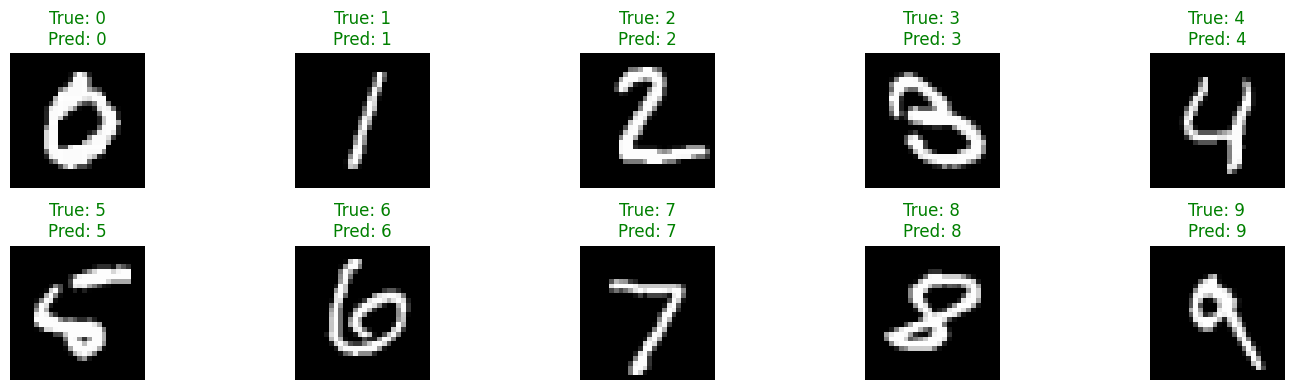

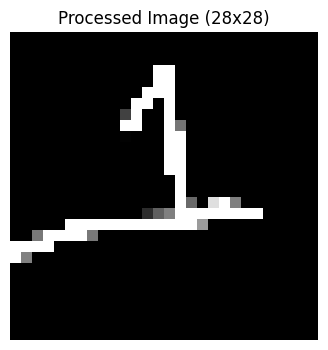

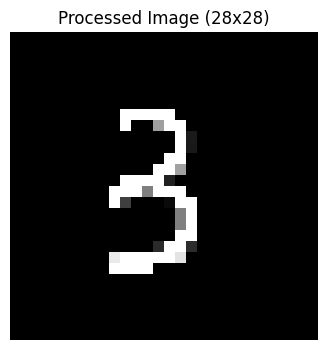

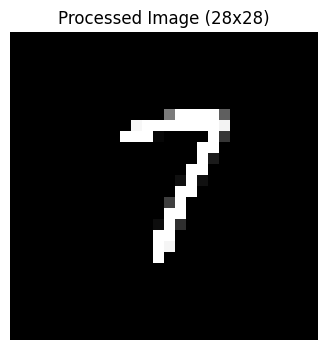

In [2]:
# ============================================
# PROJECT 2: HANDWRITTEN DIGIT RECOGNITION
# FIXED VERSION - Works perfectly!
# ============================================

# 1. IMPORT LIBRARIES
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import output
from IPython.display import HTML, display
import base64
from io import BytesIO
from PIL import Image
import io

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

# 2. LOAD MNIST DATASET
print("\n📥 Loading MNIST dataset...")
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training images: {x_train.shape}")
print(f"Testing images: {x_test.shape}")

# 3. PREPROCESS THE DATA
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

print("✅ Data preprocessing complete!")

# 4. BUILD THE NEURAL NETWORK
print("\n🔧 Building CNN model...")

model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# 5. TRAIN THE MODEL
print("\n🏋️ Training model...")
history = model.fit(
    x_train, y_train,
    epochs=3,  # Reduced for faster training
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# 6. EVALUATE THE MODEL
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n✅ Test accuracy: {test_acc*100:.2f}%")

# 7. SHOW SAMPLE PREDICTIONS
print("\n🔍 Sample predictions from test set:")
predictions = model.predict(x_test[:10])

plt.figure(figsize=(15, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    predicted_digit = np.argmax(predictions[i])
    true_digit = y_test[i]
    color = 'green' if predicted_digit == true_digit else 'red'
    plt.title(f"Pred: {predicted_digit}\nTrue: {true_digit}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

# 8. IMPROVED DRAWING INTERFACE (FIXED VERSION)
print("\n🎨 Draw a digit below and click 'Predict'")

# JavaScript for drawing canvas
drawing_html = '''
<div style="border:2px solid #4CAF50; padding:20px; border-radius:10px; max-width:400px; margin:auto; text-align:center;">
    <h3>Draw a digit (0-9):</h3>
    <canvas id="canvas" width="280" height="280"
            style="border:2px solid #333; background:white; cursor:crosshair;
                   box-shadow:0 4px 8px rgba(0,0,0,0.2); touch-action: none;"></canvas>
    <br><br>
    <div style="display:flex; gap:10px; justify-content:center;">
        <button onclick="clearCanvas()"
                style="padding:12px 24px; background:#f44336; color:white;
                       border:none; border-radius:5px; cursor:pointer; font-size:16px;">
            🧹 Clear
        </button>
        <button onclick="predictDigit()"
                style="padding:12px 24px; background:#4CAF50; color:white;
                       border:none; border-radius:5px; cursor:pointer; font-size:16px;">
            🔍 Predict
        </button>
    </div>
    <div id="result" style="margin-top:20px; font-size:24px; font-weight:bold;"></div>
</div>

<script>
var canvas = document.getElementById('canvas');
var ctx = canvas.getContext('2d');
ctx.fillStyle = 'white';
ctx.fillRect(0, 0, canvas.width, canvas.height);
ctx.lineWidth = 15;
ctx.lineCap = 'round';
ctx.lineJoin = 'round';
ctx.strokeStyle = 'black';

var drawing = false;
var lastX = 0;
var lastY = 0;

canvas.addEventListener('mousedown', startDrawing);
canvas.addEventListener('mousemove', draw);
canvas.addEventListener('mouseup', stopDrawing);
canvas.addEventListener('mouseleave', stopDrawing);

// Touch support for mobile
canvas.addEventListener('touchstart', handleTouchStart);
canvas.addEventListener('touchmove', handleTouchMove);
canvas.addEventListener('touchend', stopDrawing);

function startDrawing(e) {
    drawing = true;
    var pos = getMousePos(e);
    lastX = pos.x;
    lastY = pos.y;
    ctx.beginPath();
    ctx.moveTo(lastX, lastY);
}

function draw(e) {
    e.preventDefault();
    if (!drawing) return;

    var pos = getMousePos(e);
    var currentX = pos.x;
    var currentY = pos.y;

    ctx.lineTo(currentX, currentY);
    ctx.stroke();
    ctx.beginPath();
    ctx.moveTo(currentX, currentY);

    lastX = currentX;
    lastY = currentY;
}

function stopDrawing() {
    drawing = false;
    ctx.beginPath();
}

function getMousePos(e) {
    var rect = canvas.getBoundingClientRect();
    var scaleX = canvas.width / rect.width;
    var scaleY = canvas.height / rect.height;

    var clientX, clientY;

    if (e.touches) {
        clientX = e.touches[0].clientX;
        clientY = e.touches[0].clientY;
    } else {
        clientX = e.clientX;
        clientY = e.clientY;
    }

    var x = (clientX - rect.left) * scaleX;
    var y = (clientY - rect.top) * scaleY;

    return {x: Math.min(Math.max(x, 0), canvas.width),
            y: Math.min(Math.max(y, 0), canvas.height)};
}

function handleTouchStart(e) {
    e.preventDefault();
    startDrawing(e);
}

function handleTouchMove(e) {
    e.preventDefault();
    draw(e);
}

function clearCanvas() {
    ctx.fillStyle = 'white';
    ctx.fillRect(0, 0, canvas.width, canvas.height);
    ctx.beginPath();
    document.getElementById('result').innerHTML = '';
}

function predictDigit() {
    // Get canvas data as image
    var dataURL = canvas.toDataURL('image/png');

    // Create a temporary canvas to process the image
    var tempCanvas = document.createElement('canvas');
    tempCanvas.width = 28;
    tempCanvas.height = 28;
    var tempCtx = tempCanvas.getContext('2d');

    // Draw the canvas content scaled down to 28x28
    tempCtx.drawImage(canvas, 0, 0, 280, 280, 0, 0, 28, 28);

    // Get the image data
    var imgData = tempCtx.getImageData(0, 0, 28, 28);
    var data = [];

    // Convert to grayscale and normalize
    for (var i = 0; i < imgData.data.length; i += 4) {
        // RGB to grayscale (average of R,G,B)
        var gray = (imgData.data[i] + imgData.data[i+1] + imgData.data[i+2]) / 3;
        // Invert and normalize (MNIST has white on black)
        gray = 255 - gray;
        data.push(gray);
    }

    // Send to Python
    google.colab.kernel.invokeFunction('predict_digit', [data], {});
}
</script>
'''

display(HTML(drawing_html))

# Function to predict digit from canvas data
def predict_digit(data):
    try:
        # Convert to numpy array
        img_array = np.array(data, dtype=np.float32)

        # Check if array is empty (all white)
        if np.all(img_array < 10):  # Threshold for blank canvas
            display(HTML('''
            <div style="background:#fff3cd; padding:15px; border-radius:10px;
                        border-left:5px solid #ffc107; margin-top:10px">
                <p style="color:#856404; font-size:18px; margin:0">
                    ⚠️ Please draw a digit first!
                </p>
            </div>
            '''))
            return

        # Reshape and preprocess
        img_array = img_array.reshape(28, 28)
        img_array = img_array / 255.0  # Normalize to 0-1

        # Show the processed image
        plt.figure(figsize=(4,4))
        plt.imshow(img_array, cmap='gray')
        plt.title("Processed Image (28x28)")
        plt.axis('off')
        plt.show()

        # Reshape for model
        img_array = img_array.reshape(1, 28, 28, 1)

        # Predict
        prediction = model.predict(img_array, verbose=0)
        digit = np.argmax(prediction)
        confidence = np.max(prediction) * 100

        # Show result with color based on confidence
        color = '#4CAF50' if confidence > 70 else '#ff9800' if confidence > 40 else '#f44336'

        display(HTML(f'''
        <div style="background:#e3f2fd; padding:20px; border-radius:10px;
                    border-left:5px solid {color}; margin-top:10px;
                    box-shadow:0 2px 4px rgba(0,0,0,0.1);">
            <h2 style="color:#1976D2; margin:0; display:flex; align-items:center; gap:10px;">
                <span style="font-size:36px">✏️</span>
                <span>Predicted: <span style="font-size:64px; color:{color}">{digit}</span></span>
            </h2>
            <p style="color:#555; font-size:18px; margin:10px 0 0 0">
                Confidence: {confidence:.1f}%
            </p>
        </div>
        '''))

    except Exception as e:
        display(HTML(f'''
        <div style="background:#f8d7da; padding:15px; border-radius:10px;
                    border-left:5px solid #dc3545; margin-top:10px">
            <p style="color:#721c24; font-size:18px; margin:0">
                Error: {str(e)}
            </p>
        </div>
        '''))

# Register the function
output.register_callback('predict_digit', predict_digit)

print("\n✅ Drawing interface ready! Draw a digit and click Predict.")
print("💾 Model will be saved after testing...")

# 9. SAVE THE MODEL
model.save('mnist_digit_recognizer.keras')  # Using .keras format (recommended)
print("\n✅ Model saved as 'mnist_digit_recognizer.keras'")

# 10. TEST WITH SOME SAMPLE DIGITS FROM THE DATASET
print("\n📝 Let's also test with some digits from the test set:")

test_samples = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # One of each digit
plt.figure(figsize=(15, 4))
for i, digit in enumerate(test_samples):
    # Find first occurrence of each digit
    idx = np.where(y_test == digit)[0][0]

    # Predict
    pred = model.predict(x_test[idx].reshape(1, 28, 28, 1), verbose=0)
    pred_digit = np.argmax(pred)

    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {digit}\nPred: {pred_digit}",
              color='green' if digit == pred_digit else 'red')
    plt.axis('off')
plt.tight_layout()
plt.show()